In [1]:
import pandas as pd
auto_df = pd.read_csv("buowset_preds_96545a6b81b24794962d464e8fcbdc1d.csv")
auto_df["date"] = auto_df["file_path"].str.split("/").apply(lambda x: x[-1]).apply(lambda x: x.replace(".WAV", ""))
auto_df["date"] = pd.to_datetime(auto_df["date"], format="%Y%m%d_%H%M%S")
auto_df

,Unnamed: 0,file_path,offset,confidence,pred_label,cluck,coocoo,twitter,alarm,chick_begging,date
0,0,/mnt/restorage/Audiomoth/Raw sound files/2024/...,339,0.967754,alarm,6.906714e-05,3.649780e-07,5.186640e-06,9.677541e-01,3.334761e-05,2024-05-24 00:00:00
1,1,/mnt/restorage/Audiomoth/Raw sound files/2024/...,639,1.000000,coocoo,1.999115e-09,1.000000e+00,2.631112e-09,1.872819e-08,4.164501e-10,2024-05-24 00:00:00
2,2,/mnt/restorage/Audiomoth/Raw sound files/2024/...,846,0.533618,alarm,5.193043e-02,2.093858e-02,1.659833e-03,5.336177e-01,1.346321e-01,2024-05-24 00:00:00
3,3,/mnt/restorage/Audiomoth/Raw sound files/2024/...,1014,0.999174,cluck,9.991742e-01,3.545568e-07,2.026001e-06,1.895314e-05,5.109003e-07,2024-05-24 00:00:00
4,4,/mnt/restorage/Audiomoth/Raw sound files/2024/...,2808,1.000000,coocoo,9.541004e-10,1.000000e+00,7.490791e-10,1.744773e-09,3.226669e-10,2024-05-24 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...
224686,224686,/mnt/restorage/Audiomoth/Raw sound files/2024/...,19107,0.998127,alarm,4.633274e-05,5.040432e-06,3.640066e-06,9.981270e-01,1.104113e-03,2024-05-28 18:38:31
224687,224687,/mnt/restorage/Audiomoth/Raw sound files/2024/...,19140,0.844793,alarm,1.028857e-04,3.219901e-05,9.032261e-05,8.447932e-01,7.732322e-03,2024-05-28 18:38:31
224688,224688,/mnt/restorage/Audiomoth/Raw sound files/2024/...,19146,0.999993,alarm,1.213669e-07,3.484674e-09,1.636814e-09,9.999927e-01,7.540544e-08,2024-05-28 18:38:31
224689,224689,/mnt/restorage/Audiomoth/Raw sound files/2024/...,19149,0.987917,alarm,8.427718e-07,8.852118e-08,4.223478e-08,9.879168e-01,4.443612e-05,2024-05-28 18:38:31


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

(array([19868., 19870., 19872., 19874., 19875., 19877., 19879., 19881.]),
 [Text(19868.0, 0, '2024-05-25'),
  Text(19870.0, 0, '2024-05-27'),
  Text(19872.0, 0, '2024-05-29'),
  Text(19874.0, 0, '2024-05-31'),
  Text(19875.0, 0, '2024-06-01'),
  Text(19877.0, 0, '2024-06-03'),
  Text(19879.0, 0, '2024-06-05'),
  Text(19881.0, 0, '2024-06-07')])

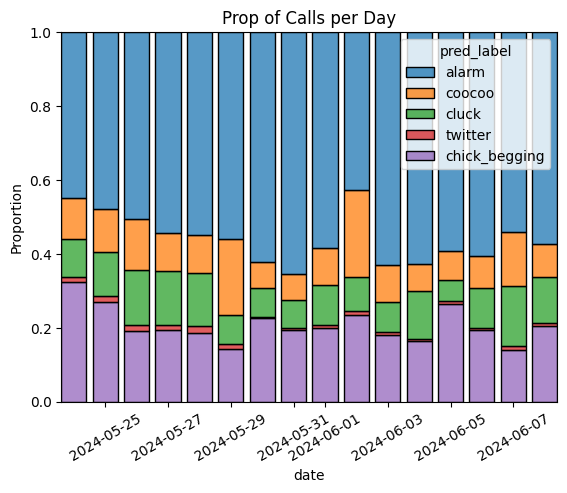

In [3]:
plt.title("Prop of Calls per Day")
g = sns.histplot(auto_df, x="date", hue="pred_label", multiple="fill", stat="proportion",
    discrete=True, shrink=.8)
plt.xticks(rotation=30)

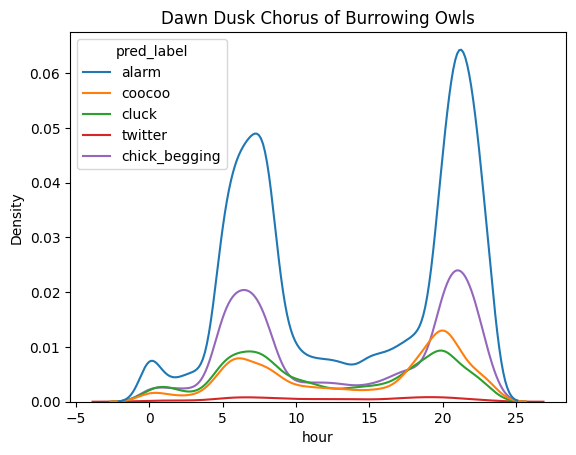

In [4]:
plt.title("Dawn Dusk Chorus of Burrowing Owls")
auto_df["hour"] = auto_df["date"].apply(lambda x: x.hour) + auto_df["offset"] // 60 // 60
g = sns.kdeplot(auto_df, x="hour", hue="pred_label")

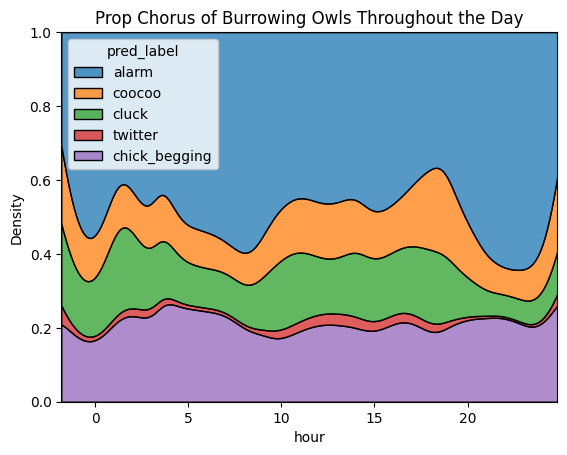

In [5]:
plt.title("Prop Chorus of Burrowing Owls Throughout the Day")
g = sns.kdeplot(auto_df, x="hour", hue="pred_label", multiple="fill")

(array([19864., 19866., 19868., 19870., 19872., 19874., 19875., 19877.,
        19879., 19881., 19883.]),
 [Text(19864.0, 0, '2024-05-21'),
  Text(19866.0, 0, '2024-05-23'),
  Text(19868.0, 0, '2024-05-25'),
  Text(19870.0, 0, '2024-05-27'),
  Text(19872.0, 0, '2024-05-29'),
  Text(19874.0, 0, '2024-05-31'),
  Text(19875.0, 0, '2024-06-01'),
  Text(19877.0, 0, '2024-06-03'),
  Text(19879.0, 0, '2024-06-05'),
  Text(19881.0, 0, '2024-06-07'),
  Text(19883.0, 0, '2024-06-09')])

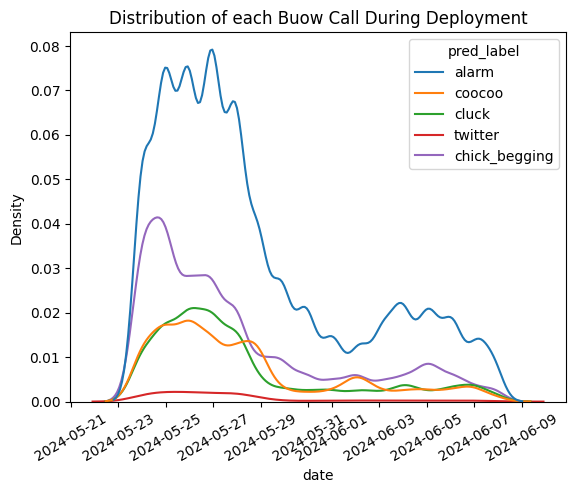

In [6]:
plt.title("Distribution of each Buow Call During Deployment")
g = sns.kdeplot(auto_df, x="date", hue="pred_label")
plt.xticks(rotation=30)

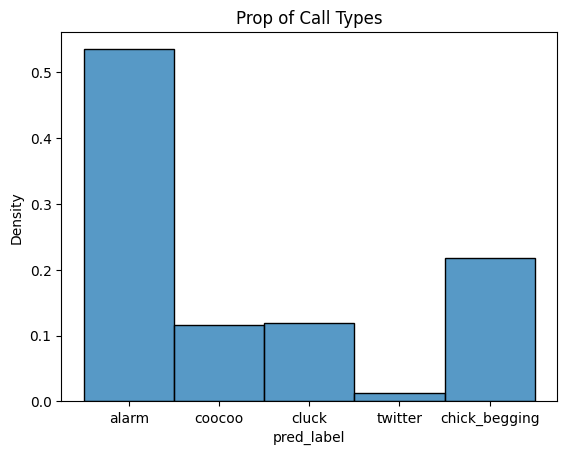

In [7]:
plt.title("Prop of Call Types")
g = sns.histplot(auto_df, x="pred_label", stat="density")

<Axes: title={'center': 'Distribution of Model Confidence'}>

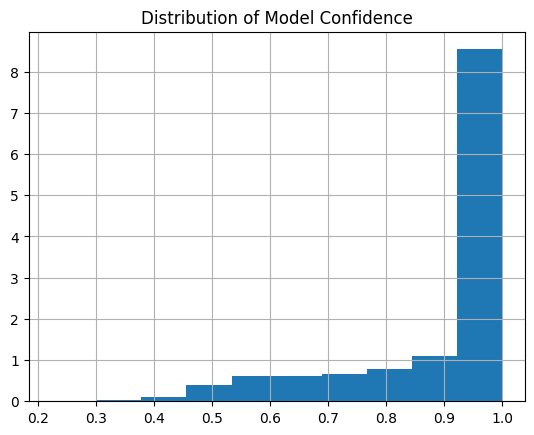

In [8]:
plt.title("Distribution of Model Confidence")
auto_df["confidence"].hist(density=True)

In [9]:
auto_df

,Unnamed: 0,file_path,offset,confidence,pred_label,cluck,coocoo,twitter,alarm,chick_begging,date,hour
0,0,/mnt/restorage/Audiomoth/Raw sound files/2024/...,339,0.967754,alarm,6.906714e-05,3.649780e-07,5.186640e-06,9.677541e-01,3.334761e-05,2024-05-24 00:00:00,0
1,1,/mnt/restorage/Audiomoth/Raw sound files/2024/...,639,1.000000,coocoo,1.999115e-09,1.000000e+00,2.631112e-09,1.872819e-08,4.164501e-10,2024-05-24 00:00:00,0
2,2,/mnt/restorage/Audiomoth/Raw sound files/2024/...,846,0.533618,alarm,5.193043e-02,2.093858e-02,1.659833e-03,5.336177e-01,1.346321e-01,2024-05-24 00:00:00,0
3,3,/mnt/restorage/Audiomoth/Raw sound files/2024/...,1014,0.999174,cluck,9.991742e-01,3.545568e-07,2.026001e-06,1.895314e-05,5.109003e-07,2024-05-24 00:00:00,0
4,4,/mnt/restorage/Audiomoth/Raw sound files/2024/...,2808,1.000000,coocoo,9.541004e-10,1.000000e+00,7.490791e-10,1.744773e-09,3.226669e-10,2024-05-24 00:00:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...
224686,224686,/mnt/restorage/Audiomoth/Raw sound files/2024/...,19107,0.998127,alarm,4.633274e-05,5.040432e-06,3.640066e-06,9.981270e-01,1.104113e-03,2024-05-28 18:38:31,23
224687,224687,/mnt/restorage/Audiomoth/Raw sound files/2024/...,19140,0.844793,alarm,1.028857e-04,3.219901e-05,9.032261e-05,8.447932e-01,7.732322e-03,2024-05-28 18:38:31,23
224688,224688,/mnt/restorage/Audiomoth/Raw sound files/2024/...,19146,0.999993,alarm,1.213669e-07,3.484674e-09,1.636814e-09,9.999927e-01,7.540544e-08,2024-05-28 18:38:31,23
224689,224689,/mnt/restorage/Audiomoth/Raw sound files/2024/...,19149,0.987917,alarm,8.427718e-07,8.852118e-08,4.223478e-08,9.879168e-01,4.443612e-05,2024-05-28 18:38:31,23


In [10]:
# import birdnet

In [11]:
# from birdnet.models.v2m4 import 

In [12]:
# from pathlib import Path
# # from birdnet.models import ModelV2M4

# # # create model instance for v2.4
# # model = ModelV2M4()

# # # predict species within the whole audio file
# # species_in_area = model.predict_species_at_location_and_time(32.715736, -117.161087, week=None)
# # predictions = model.predict_species_within_audio_file(
# #    Path(auto_df.iloc[0]["file_path"]),
# #    filter_species=set(species_in_area.keys())
# # )

# # # get most probable prediction at time interval 0s-3s
# # prediction, confidence = list(predictions[(0.0, 3.0)].items())[0]
# # print(f"predicted '{prediction}' with a confidence of {confidence:.6f}")
# # # predicted 'Poecile atricapillus_Black-capped Chickadee' with a confidence of 0.814056

# from birdnet import predict_species_within_audio_files_mp

# files = [Path(x) for x in auto_df["file_path"].unique()]

# file_predictions = list(predict_species_within_audio_files_mp(files))

# for file, predictions in file_predictions:
#   print(file.name, len(predictions), "predictions")

In [13]:
import librosa
auto_df["clip_length"] = auto_df["file_path"].apply(lambda x : librosa.get_duration(path=x))

<Axes: >

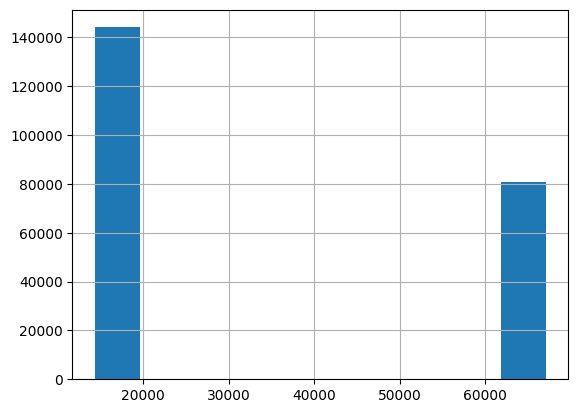

In [14]:
auto_df["clip_length"].hist()

Text(0.5, 1.0, 'The recording started during that day and might have continued to the next')

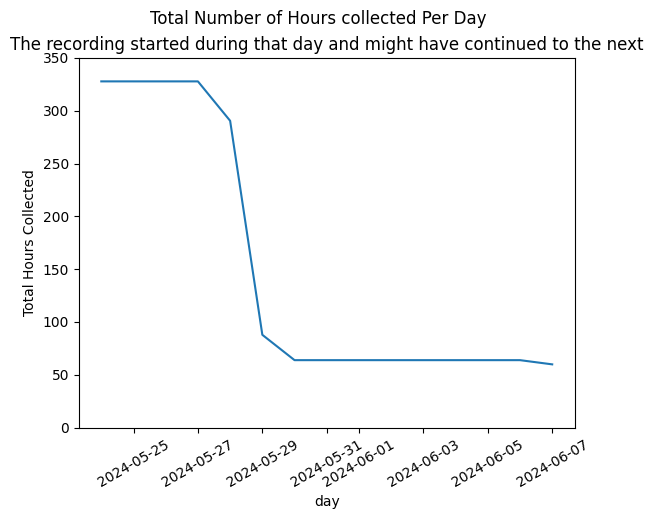

In [72]:
recording_dur = auto_df[["date", "clip_length", "mic_id"]].drop_duplicates()
recording_dur["day"] = recording_dur.apply("date").apply(lambda x: x.date())
recording_dur.groupby("day")["clip_length"].apply(lambda df: df.sum()/(60 * 60)).plot()
plt.xticks(rotation=30)
# plt.xlim(2, 8)  # Set x-axis limits from 2 to 8
plt.ylim(0, 350) # Set y-axis limits from -0.5 to 0.5
plt.ylabel("Total Hours Collected")
plt.suptitle("Total Number of Hours collected Per Day")
plt.title("The recording started during that day and might have continued to the next")

In [ ]:
auto_df["clip_length"] = auto_df["file_path"].apply(lambda x : librosa.get_duration(path=x))
auto_df["mic_id"] = auto_df["file_path"].str.extract(r"-(\d+_\d+_\w+)/")

<Axes: xlabel='day'>

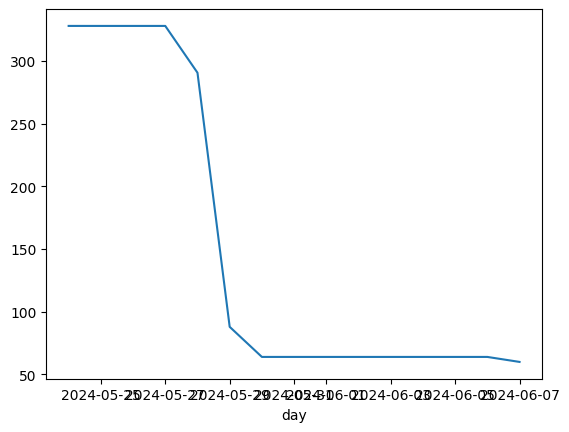

In [ ]:
recording_dur = auto_df[["date", "clip_length", "mic_id"]].drop_duplicates()
recording_dur["day"] = recording_dur.apply("date").apply(lambda x: x.date())
recording_dur.groupby("day")["clip_length"].apply(lambda df: df.sum()/(60 * 60)).plot()

In [73]:
auto_df["clip_length"] = auto_df["file_path"].apply(lambda x : librosa.get_duration(path=x))
auto_df["mic_id"] = auto_df["file_path"].str.extract(r"-(\d+_\d+_\w+)/")
recording_dur = auto_df[["date", "clip_length", "mic_id"]].drop_duplicates()
recording_dur["day"] = recording_dur.apply("date").apply(lambda x: x.date())
recording_dur["is_continous"] = recording_dur["mic_id"].str.contains("cont")
recording_dur_by_day_and_cont = recording_dur.groupby(["day", "is_continous"])["clip_length"].apply(lambda df: df.sum()/(60*60)).reset_index()
recording_dur_by_day_and_cont

,day,is_continous,clip_length
0,2024-05-24,False,63.866667
1,2024-05-24,True,263.991111
2,2024-05-25,False,63.866667
3,2024-05-25,True,263.986389
4,2024-05-26,False,63.866667
5,2024-05-26,True,263.986389
6,2024-05-27,False,63.866667
7,2024-05-27,True,263.987222
8,2024-05-28,False,55.900000
9,2024-05-28,True,234.631111


Text(0.5, 1.0, 'The recording started during that day and might have continued to the next')

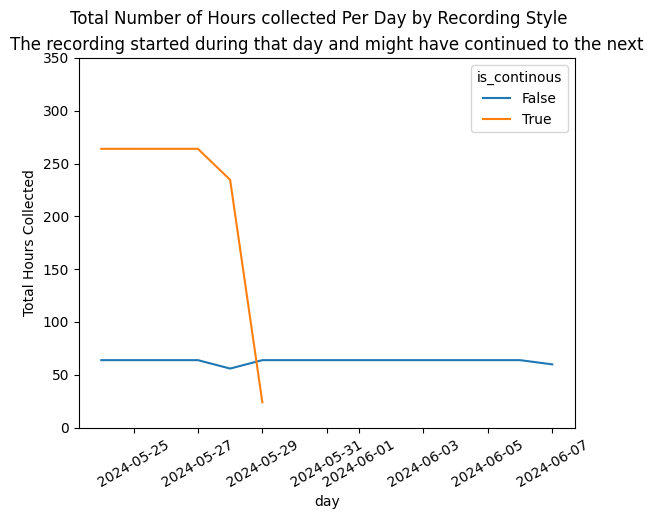

In [75]:
g = sns.lineplot(recording_dur_by_day_and_cont, x="day", y="clip_length", hue="is_continous")
plt.xticks(rotation=30)
# plt.xlim(2, 8)  # Set x-axis limits from 2 to 8
plt.ylim(0, 350) # Set y-axis limits from -0.5 to 0.5
plt.ylabel("Total Hours Collected")
plt.suptitle("Total Number of Hours collected Per Day by Recording Style")
plt.title("The recording started during that day and might have continued to the next")

Text(0.5, 1.0, 'The recording started during that hour and might have continued to the next')

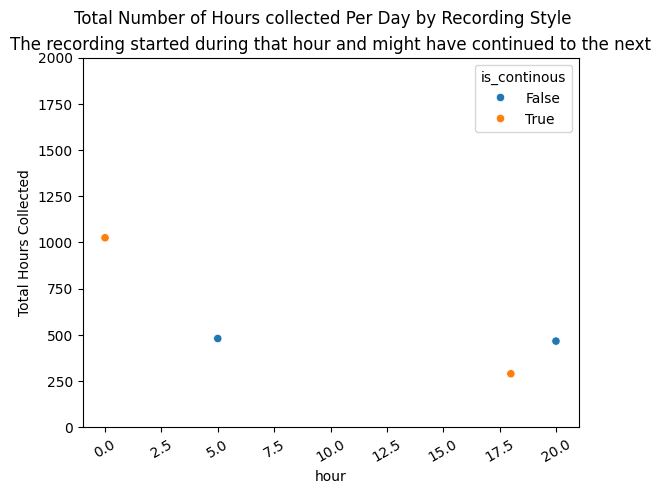

In [79]:
recording_dur["hour"] = recording_dur.apply("date").apply(lambda x: x.hour)
recording_dur["is_continous"] = recording_dur["mic_id"].str.contains("cont")
recording_dur_by_day_and_cont = recording_dur.groupby(["hour", "is_continous"])["clip_length"].apply(lambda df: df.sum()/(60*60)).reset_index()
recording_dur_by_day_and_cont
g = sns.scatterplot(recording_dur_by_day_and_cont, x="hour", y="clip_length", hue="is_continous")
plt.xticks(rotation=30)
# plt.xlim(2, 8)  # Set x-axis limits from 2 to 8
plt.ylim(0, 2000) # Set y-axis limits from -0.5 to 0.5
plt.ylabel("Total Hours Collected")
plt.suptitle("Total Number of Hours collected Per Day by Recording Style")
plt.title("The recording started during that hour and might have continued to the next")

In [102]:
recording_dur_by_day_and_cont

,hour,is_continous,clip_length
0,0,True,1025.261111
1,5,False,480.000000
2,18,True,289.320000
3,20,False,466.050000


# Split the continous and non continous recordings

Text(0.5, 0.98, 'Dawn Dusk Chorus of Burrowing Owls')

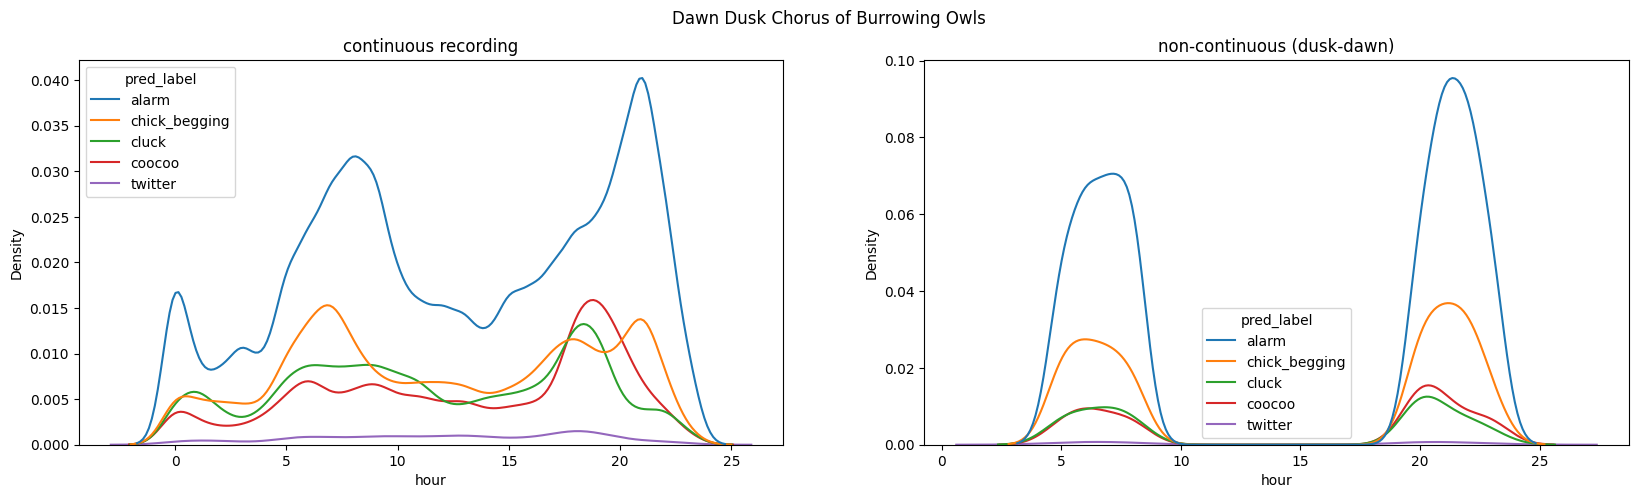

In [107]:
bw_adjust= 0.75


fig, axs = plt.subplots(ncols=2, figsize=(20,5))


auto_df = auto_df.sort_values("pred_label")
auto_df["hour"] = auto_df["date"].apply(lambda x: x.hour) + auto_df["offset"] // 60 // 60


sns.kdeplot(auto_df[auto_df["mic_id"].str.contains("cont")], x="hour", hue="pred_label", ax=axs[0],  bw_adjust=bw_adjust,)
axs[0].set_title("continuous recording")
axs[1].set_title("non-continuous (dusk-dawn)")
sns.kdeplot(auto_df[~auto_df["mic_id"].str.contains("cont")], x="hour", hue="pred_label", ax=axs[1],  bw_adjust=bw_adjust,)
plt.suptitle("Dawn Dusk Chorus of Burrowing Owls")

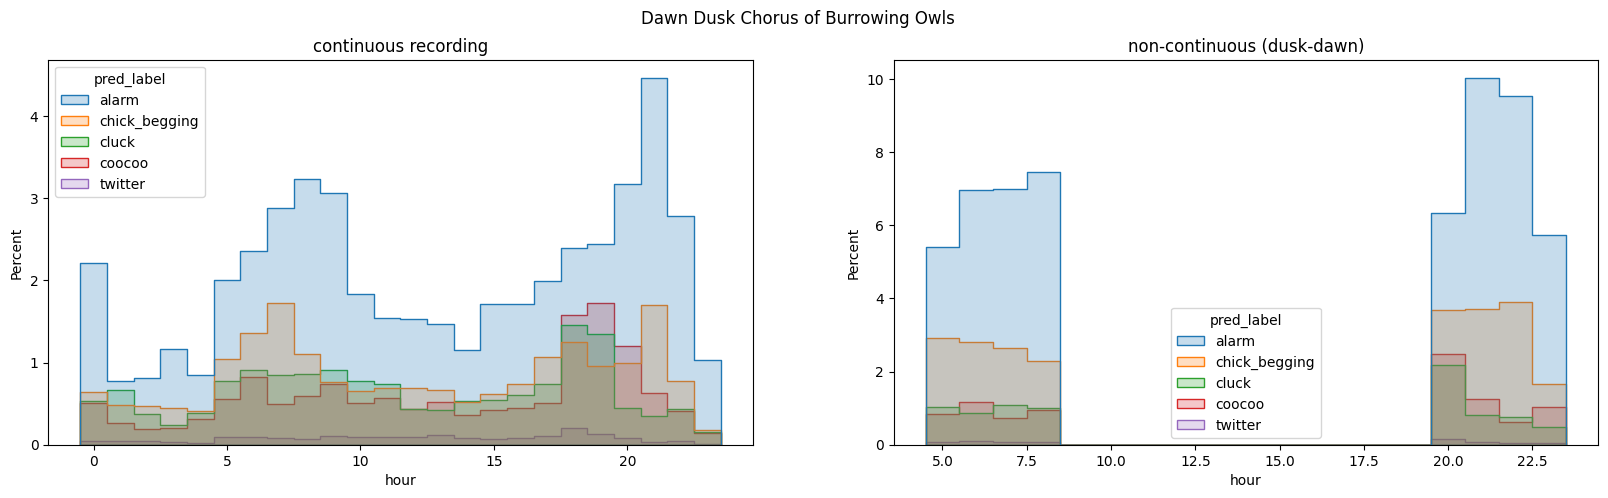

In [108]:
fig, axs = plt.subplots(ncols=2, figsize=(20,5))
sns.histplot(auto_df[auto_df["mic_id"].str.contains("cont")], x="hour", hue="pred_label", ax=axs[0], element="step",  stat="percent", discrete=True)
axs[0].set_title("continuous recording")
axs[1].set_title("non-continuous (dusk-dawn)")
sns.histplot(auto_df[~auto_df["mic_id"].str.contains("cont")], x="hour", hue="pred_label", ax=axs[1], element="step",  stat="percent", discrete=True)
plt.suptitle("Dawn Dusk Chorus of Burrowing Owls")
plt.show()

## Over time

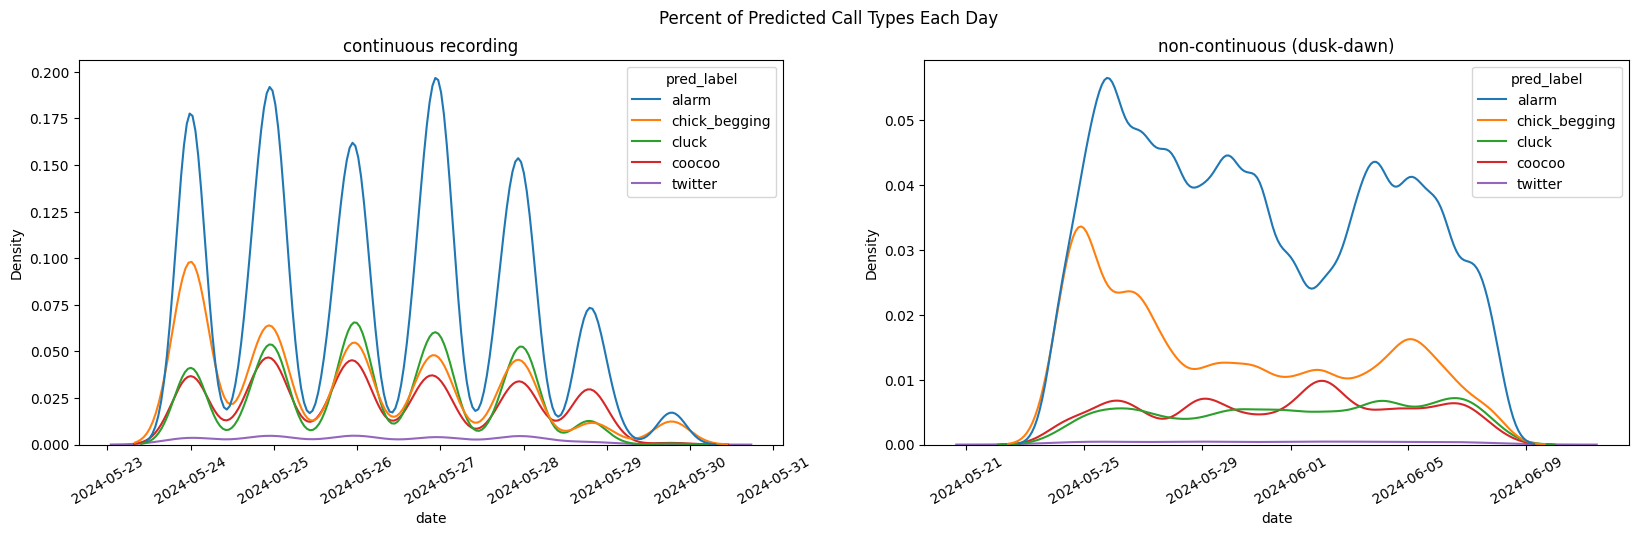

In [115]:
# plt.title("Distribution of each Buow Call During Deployment")
# g = sns.kdeplot(auto_df, x="date", hue="pred_label")
# plt.xticks(rotation=30)


fig, axs = plt.subplots(ncols=2, figsize=(20,5))
sns.kdeplot(auto_df[auto_df["mic_id"].str.contains("cont")], x="date", hue="pred_label", ax=axs[0])
axs[0].set_title("continuous recording")
axs[0].tick_params(axis='x', rotation=30)
axs[1].set_title("non-continuous (dusk-dawn)")
axs[1].tick_params(axis='x', rotation=30)
sns.kdeplot(auto_df[~auto_df["mic_id"].str.contains("cont")], x="date", hue="pred_label", ax=axs[1],)
plt.suptitle("Percent of Predicted Call Types Each Day")
plt.show()

In [ ]:
ig, axs = plt.subplots(ncols=2, figsize=(20,5))
sns.kdpe(auto_df[auto_df["mic_id"].str.contains("cont")], x="date", hue="pred_label", ax=axs[0], element="step",  stat="percent", discrete=True)
axs[0].set_title("continuous recording")
axs[0].tick_params(axis='x', rotation=30)
axs[1].set_title("non-continuous (dusk-dawn)")
axs[1].tick_params(axis='x', rotation=30)
sns.histplot(auto_df[~auto_df["mic_id"].str.contains("cont")], x="date", hue="pred_label", ax=axs[1], element="step",  stat="percent", discrete=True)
plt.suptitle("Percent of Predicted Call Types Each Day")
plt.show()

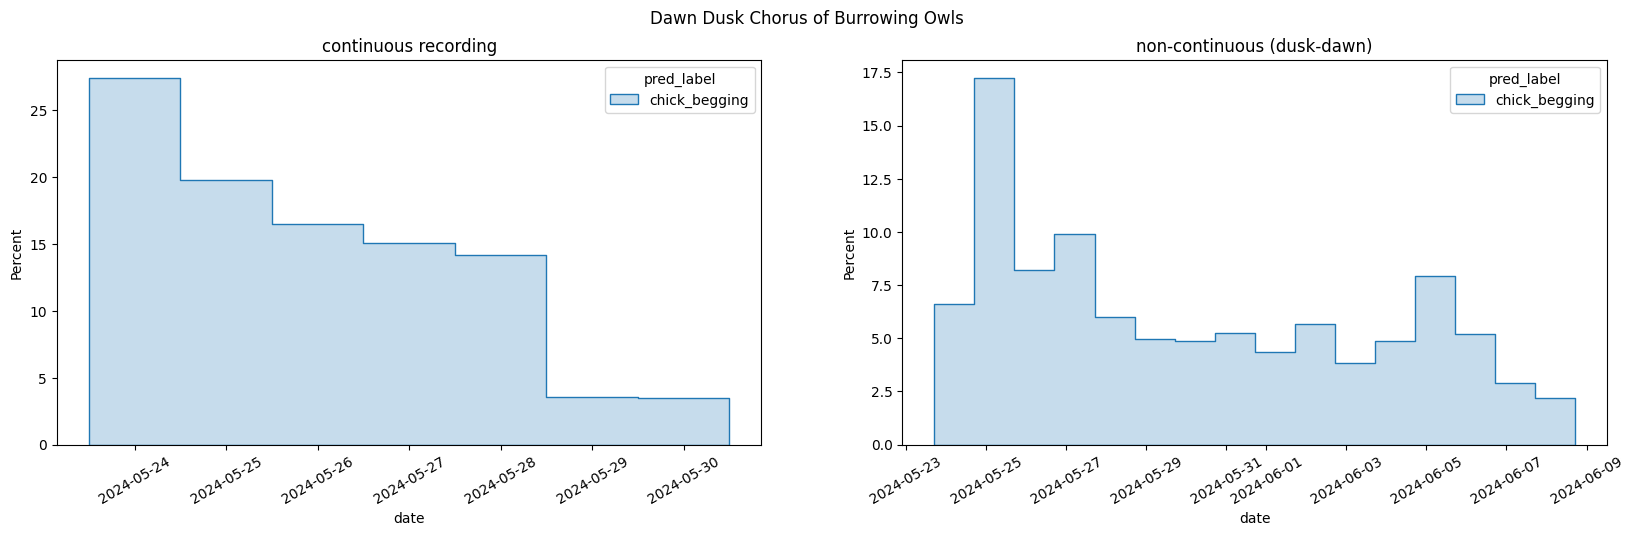

In [120]:
fig, axs = plt.subplots(ncols=2, figsize=(20,5))
sns.histplot(auto_df[auto_df["mic_id"].str.contains("cont") & auto_df["pred_label"].str.contains("chick")], x="date", hue="pred_label", ax=axs[0], element="step",  stat="percent", discrete=True)
axs[0].set_title("continuous recording")
axs[0].tick_params(axis='x', rotation=30)
axs[1].set_title("non-continuous (dusk-dawn)")
axs[1].tick_params(axis='x', rotation=30)
sns.histplot(auto_df[~auto_df["mic_id"].str.contains("cont") & auto_df["pred_label"].str.contains("chick")], x="date", hue="pred_label", ax=axs[1], element="step",  stat="percent", discrete=True)
plt.suptitle("Dawn Dusk Chorus of Burrowing Owls")
plt.show()